In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
from textwrap import fill
import numpy as np
import pandas as pd
import scanpy.external as sce
import scanpy as sc
import anndata as an
from scipy.spatial.distance import cdist
import scvelo as scv
# import gget
import re
# import rapids_singlecell as rsc
from scipy.stats import linregress
from scipy.stats import spearmanr
from sklearn.preprocessing import MinMaxScaler
from scipy.stats import zscore
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from tqdm import tqdm
from statsmodels.stats.multitest import multipletests

# import cellrank as cr

sc.settings.verbosity = 3 

print(scv.__version__)

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('py.warnings').setLevel(logging.ERROR)

0.3.3


In [2]:
print(np.__version__)

1.26.4


In [29]:
import warnings
warnings.filterwarnings("ignore")

# Load expression

In [3]:
%%time
path = "/nfs/turbo/umms-indikar/shared/projects/hybrid_reprogramming/anndata/processed_all_groups.h5ad"
adata = sc.read_h5ad(path)
adata.X = adata.layers['log_norm'].copy()

sc.logging.print_memory_usage()
adata

Memory usage: current 2.16 GB, difference +2.16 GB
CPU times: user 635 ms, sys: 2.5 s, total: 3.13 s
Wall time: 5.01 s


AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'filter_pass', 'highly_variable', 'highly_variable_rank', 'm

In [3]:
adata.obs['cluster_str'].value_counts()

cluster_str
C4    6482
C3    3554
C2    3100
C1    2720
C5      94
Name: count, dtype: int64

In [4]:
adata.obs['leiden_split'].value_counts()

leiden_split
C1    6078
H1    2060
P2    1508
P1    1166
C2     824
H2     769
P3     756
M2     729
M1     706
M3     674
H3     622
C3      58
Name: count, dtype: int64

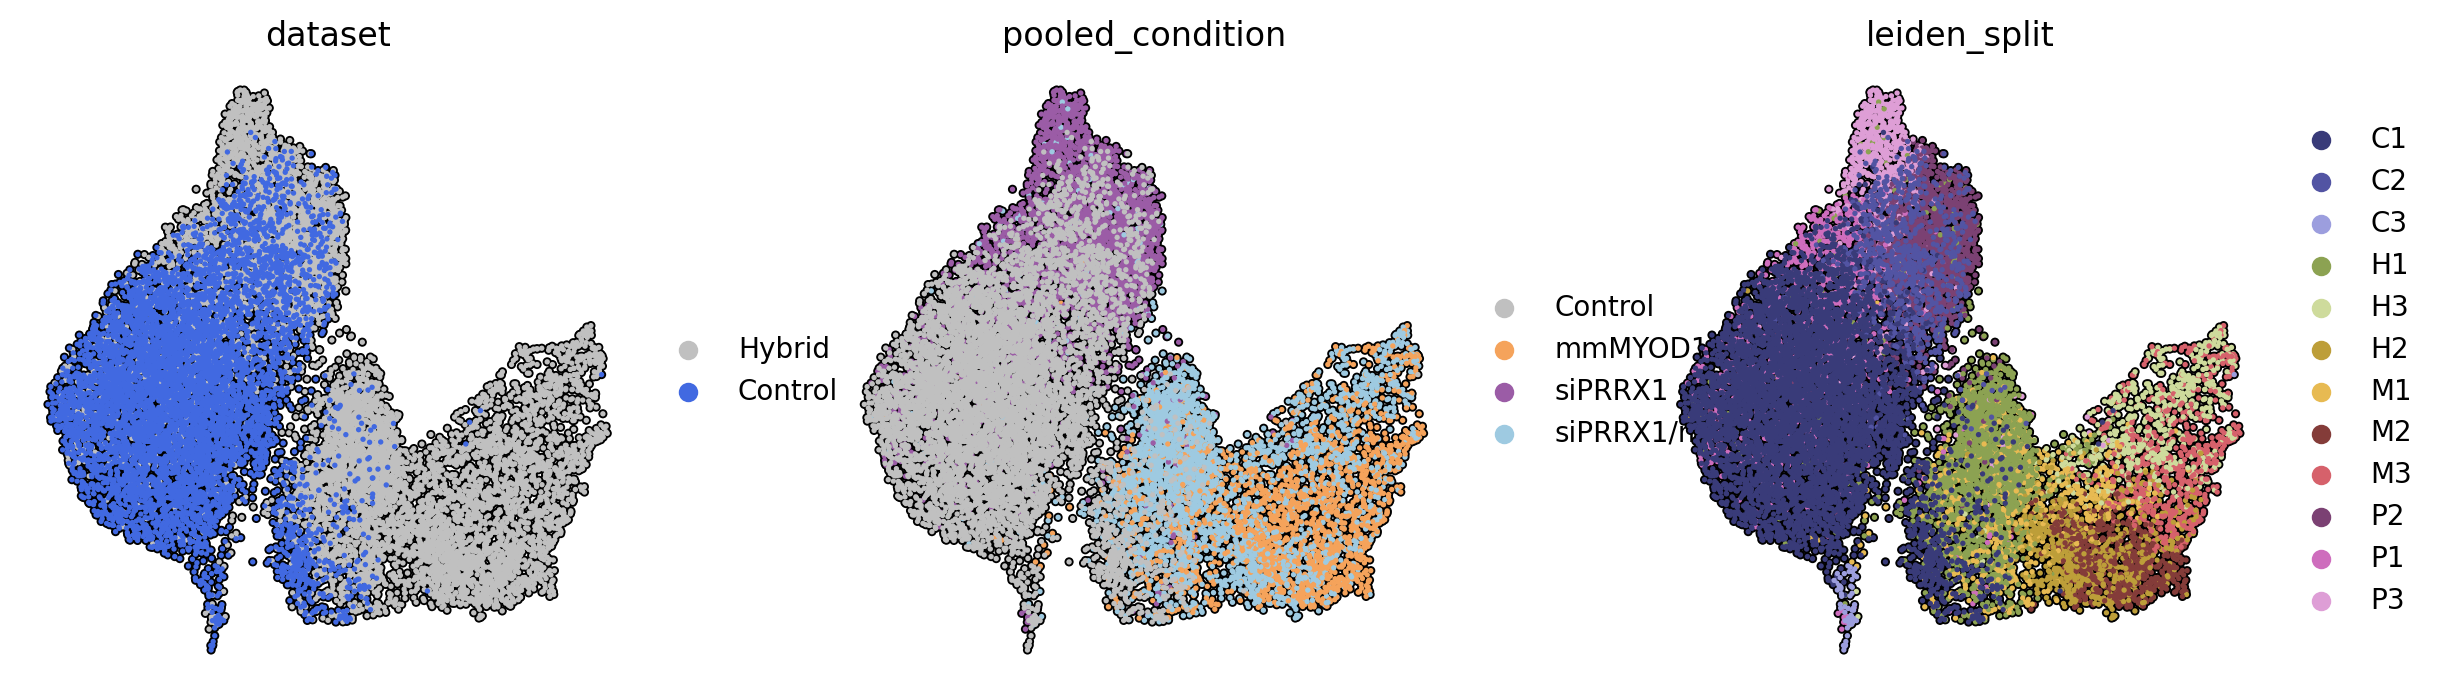

In [5]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    color=['dataset', 'pooled_condition', 'leiden_split'],
    size=15,
    ncols=3,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    alpha=1,
)

In [7]:
adata.obs.head()

,MYOD-fb_counts,PRRX1-fb_counts,PRRX1_MYOD-fb_counts,assigned_condition,total_fb_counts,condition_counts_rate,G1-fb_counts,G2M-fb_counts,S-fb_counts,dataset,...,log1p_total_counts_ribo,pct_counts_ribo,outlier,mt_outlier,S_score,G2M_score,phase,leiden,cluster_str,leiden_split
AAACCAAAGCAACTGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,7.992269,15.716183,False,False,-0.635702,4.894103,G2M,0,C1,H1
AAACCAAAGTAGGGCA_hybrid,14.0,1.0,1.0,MYOD,16.0,0.875000,NaN,NaN,NaN,Hybrid,...,7.290293,15.135860,False,False,0.306563,-0.046410,S,1,C2,M1
AAACCAAAGTCTAGGC_hybrid,0.0,0.0,25.0,PRRX1_MYOD,25.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.283494,13.937025,False,False,-1.015544,-1.571282,G1,0,C1,H1
AAACCATTCACGTAAT_hybrid,2.0,19.0,2.0,PRRX1,23.0,0.826087,NaN,NaN,NaN,Hybrid,...,7.260523,14.684015,False,False,0.139403,3.017692,G2M,2,C3,P2
AAACCATTCAGGCAGA_hybrid,0.0,22.0,0.0,PRRX1,22.0,1.000000,NaN,NaN,NaN,Hybrid,...,8.080856,17.547386,False,False,-0.391932,4.534103,G2M,2,C3,P2


# Load velocity

In [5]:
ldata = sc.read_loom("/scratch/indikar_root/indikar1/shared_data/hybrid_velocyto/merged_QZ8AH.loom")
ldata.var_names_make_unique()

# ldata.obs['velocyto_cell_id'] = ldata.obs_names.copy()
# ldata.obs['cell_id'] = ldata.obs['velocyto_cell_id'].apply(lambda x: x.split(":")[1][:-1] + "-1")

ldata.obs.head()

""
CellID
merged_QZ8AH:AAACGGGTCCTGATAGx
merged_QZ8AH:AAATGAGTCCACCGTCx
merged_QZ8AH:AAATGCAAGGTCACGTx
merged_QZ8AH:AAAGCCTCACATATAGx
merged_QZ8AH:AAACCATTCACGTAATx


In [6]:
ldata.obs['velocyto_cell_id'] = ldata.obs_names.copy()
ldata.obs['cell_id'] = ldata.obs['velocyto_cell_id'].apply(lambda x: x.split(":")[1][:-1] + "-1")

ldata.obs.head()

,velocyto_cell_id,cell_id
CellID,,
merged_QZ8AH:AAACGGGTCCTGATAGx,merged_QZ8AH:AAACGGGTCCTGATAGx,AAACGGGTCCTGATAG-1
merged_QZ8AH:AAATGAGTCCACCGTCx,merged_QZ8AH:AAATGAGTCCACCGTCx,AAATGAGTCCACCGTC-1
merged_QZ8AH:AAATGCAAGGTCACGTx,merged_QZ8AH:AAATGCAAGGTCACGTx,AAATGCAAGGTCACGT-1
merged_QZ8AH:AAAGCCTCACATATAGx,merged_QZ8AH:AAAGCCTCACATATAGx,AAAGCCTCACATATAG-1
merged_QZ8AH:AAACCATTCACGTAATx,merged_QZ8AH:AAACCATTCACGTAATx,AAACCATTCACGTAAT-1


In [8]:
%%time

fpaths = {
    "hybrid" : "/scratch/indikar_root/indikar1/shared_data/hybrid_velocyto/merged_QZ8AH.loom",
    "control" : "/scratch/indikar_root/indikar1/shared_data/fib_velocyto/merged_PW6SH.loom",
}

ldatas = []
for key, fpath in fpaths.items():
    print(f"Working {key}...")

    ldata = sc.read_loom(fpath)
    ldata.var_names_make_unique()

    # set the cell-ids back to barcodes
    ldata.obs['velocyto_cell_id'] = ldata.obs_names.copy()
    ldata.obs['cell_id'] = ldata.obs['velocyto_cell_id'].apply(lambda x: x.split(":")[1][:-1])# + "-1")
    
    if key == 'control':
        ldata.obs['cell_id'] = ldata.obs['cell_id'] + '_control'
    else:
        ldata.obs['cell_id'] = ldata.obs['cell_id'] + '_hybrid'
        
    ldata.obs_names = ldata.obs['cell_id'].values

    # Print initial cell counts
    print(f"\tInitial cell count in ldata: {ldata.shape[0]}")
    print(f"\tInitial cell count in adata: {adata.shape[0]}")
    
    # IDs not retained in ldata
    removed_from_ldata = ldata.obs.index[~ldata.obs.index.isin(adata.obs_names)].tolist()
    
    # IDs not retained in adata
    removed_from_adata = adata.obs.index[~adata.obs.index.isin(ldata.obs_names)].tolist()
    
    # Filter ldata to keep only cells present in adata
    initial_ldata_count = ldata.shape[0]
    ldata = ldata[ldata.obs.index.isin(adata.obs_names), :].copy()
    print(f"\tFiltered ldata: {ldata.shape[0]} cells kept, {initial_ldata_count - ldata.shape[0]} cells removed")

    ldatas.append(ldata)

    
ldata = an.concat(ldatas)   
ldata

Working hybrid...
	Initial cell count in ldata: 10895
	Initial cell count in adata: 15950
	Filtered ldata: 8990 cells kept, 1905 cells removed
Working control...
	Initial cell count in ldata: 8963
	Initial cell count in adata: 15950
	Filtered ldata: 6960 cells kept, 2003 cells removed
CPU times: user 47.8 s, sys: 13.1 s, total: 1min
Wall time: 1min 1s


AnnData object with n_obs × n_vars = 15950 × 38606
    obs: 'velocyto_cell_id', 'cell_id'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

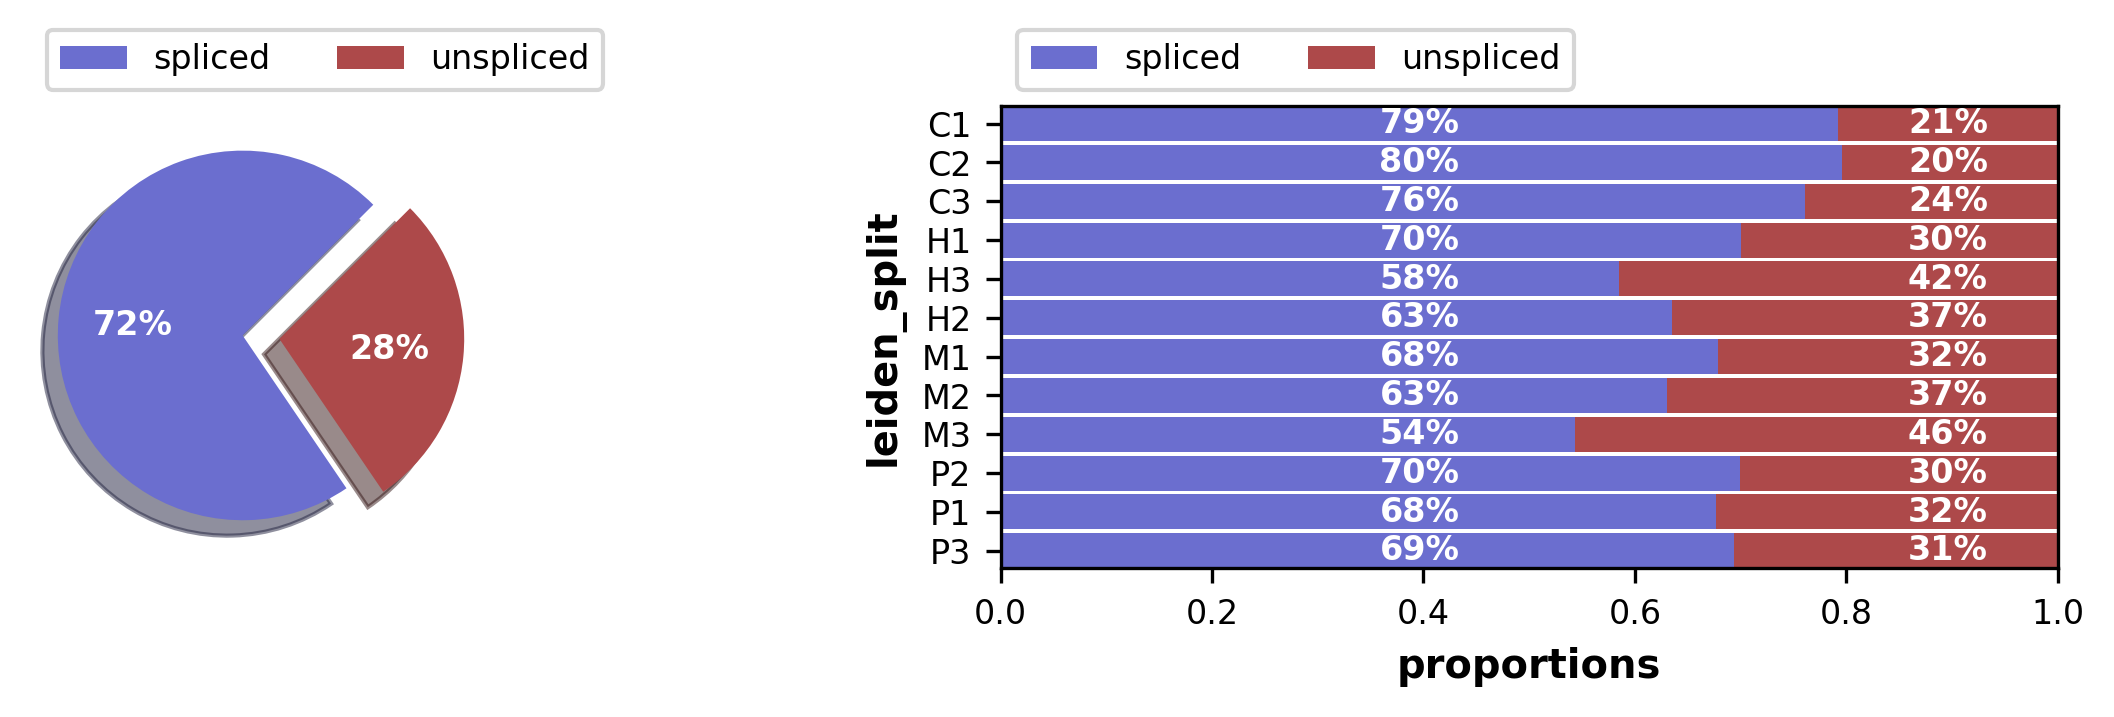

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size'
    var: 'gene_id', 'gene_type', 'Chromosome', 'Start', 'End', 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts

In [9]:
adata = scv.utils.merge(adata, ldata)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 7, 5

scv.pl.proportions(adata,
                   groupby='leiden_split',
                   dpi=300,
                   layers=['spliced', 'unspliced'],
                  )

adata

In [10]:
%%time
sc.pp.neighbors(adata, n_neighbors=150, use_rep='X_pca_harmony')
scv.pp.moments(adata, use_rep='X_pca_harmony')

scv.tl.recover_dynamics(adata, n_jobs=8) 

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:49)
Normalized count data: spliced, unspliced.
computing moments based on connectivities
    finished (0:00:15) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)
recovering dynamics (using 8/36 cores)
or disable the progress bar using `show_progress_bar=False`.


/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2378817) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:10:54) --> added 
    'fit_pars', fitted parameters for splicing dynamics (adata.var)
CPU times: user 3min 57s, sys: 54.4 s, total: 4min 51s
Wall time: 12min 3s


computing velocities
    finished (0:00:48) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)
        Consider computing the graph in an unbiased manner 
        on full expression space by not specifying basis.

computing velocity graph (using 8/36 cores)


/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/multiprocessing/popen_fork.py:67: DeprecationWarning: This process (pid=2378817) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:27) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:05) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-

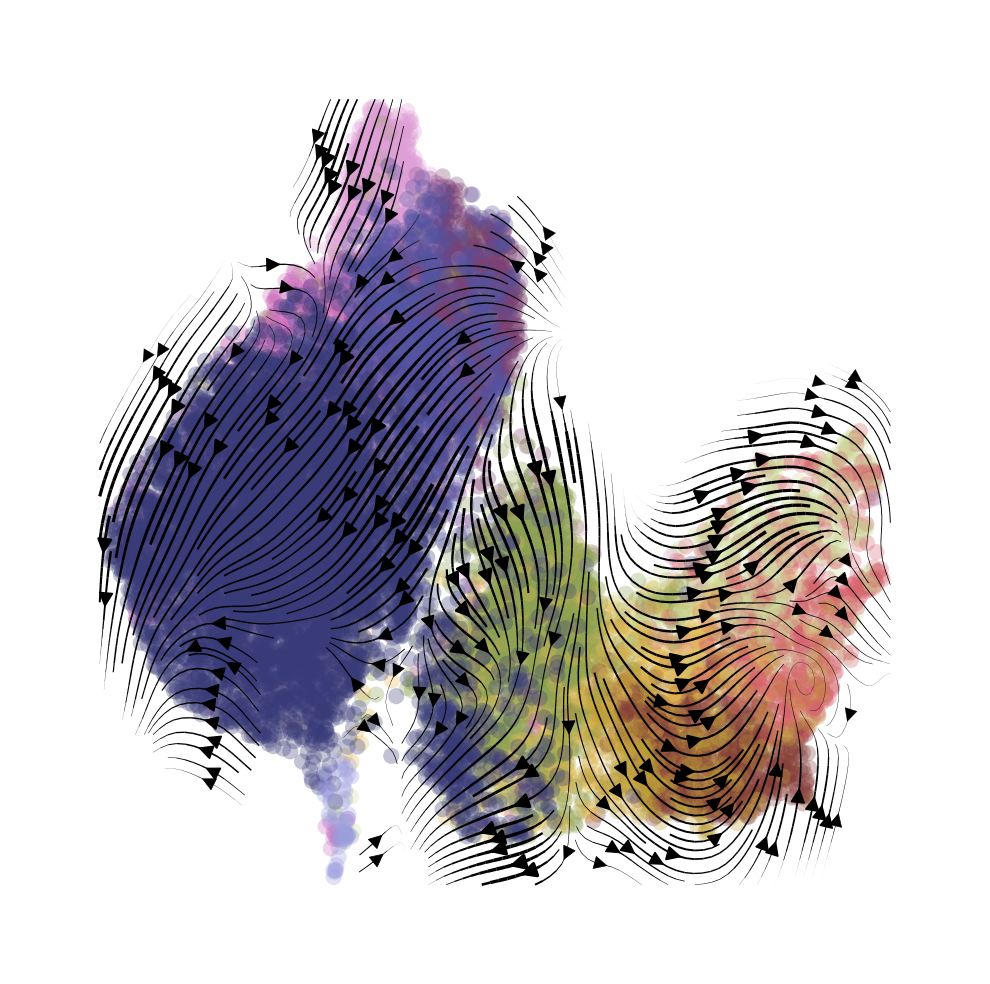

CPU times: user 46.5 s, sys: 33.7 s, total: 1min 20s
Wall time: 1min 24s


In [14]:
%%time
scv.tl.velocity(adata, mode='dynamical')
# scv.tl.velocity(adata)

scv.tl.velocity_graph(
    adata, 
    n_jobs=8,
    basis='X_pca_harmony',
    n_neighbors=150,
)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

scv.pl.velocity_embedding_stream(
    adata, 
    density=(3, 3),
    basis='X_umap',#'X_draw_graph_fa',
    color='leiden_split',
    smooth=True,
    title="",
    legend_loc='none',
    # legend_loc='right_margin',
    linewidth=0.5,
    arrow_size=0.75,
    add_margin=0.1,
)

# Pseudotime

G1: root_id='ATGGTCATCAGTTACG_control' root_key=10820
G2M: root_id='CATCCAGGTAGGCCAG_control' root_key=11401


/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-indikar/Cooper/conda_envs/scvelo/lib/python3.13/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/nfs/turbo/umms-

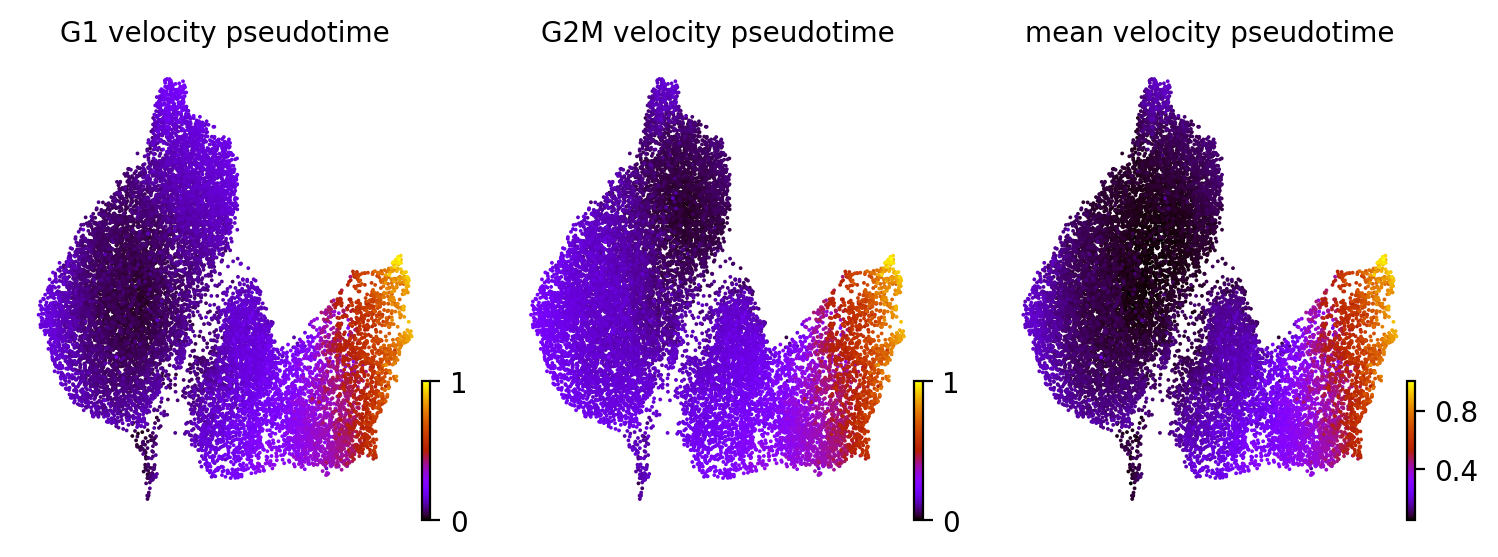

CPU times: user 24.7 s, sys: 27.9 s, total: 52.6 s
Wall time: 46.7 s


In [15]:
%%time
def find_closest_cell(adata, obs_key='barcoded_phase', value='G1', obsm_key='X_pca'):
    """
    Find the cell closest to a median vector in PCA space.

    Parameters:
        adata (AnnData): Annotated data matrix.
        obs_key (str): Key in adata.obs indicating group
        value (str): The value for aggregation 
        obsm_key (str): Key in adata.obsm for PCA or other embedding.

    Returns:
        tuple: (cell_id (str), index (int)) of the closest G1 cell in adata.obs_names
    """
    mask = adata.obs[obs_key] == value
    emb = adata.obsm[obsm_key][mask]

    median_vec = np.median(emb, axis=0)
    dists = cdist(emb, median_vec.reshape(1, -1)).flatten()
    closest_idx = np.argmin(dists)

    cell_id = adata.obs_names[mask][closest_idx]
    cell_index = np.where(adata.obs_names == cell_id)[0][0]

    return cell_id, cell_index

# loop through initial state
for phase, cluster in zip(['G1', 'G2M'], ['C1', 'C2']):
    root_id, root_key = find_closest_cell(
        adata,
        obs_key='leiden_split',
        value=cluster,
        obsm_key='X_pca_harmony',
    )

    print(f"{phase}: {root_id=} {root_key=}")

    scv.tl.velocity_pseudotime(adata, root_key=root_key)
    adata.obs[f'{phase}_velocity_pseudotime'] = adata.obs['velocity_pseudotime']


adata.obs['mean_velocity_pseudotime'] = adata.obs[['G1_velocity_pseudotime', 'G2M_velocity_pseudotime']].mean(axis=1)


plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

scv.pl.scatter(
    adata, 
    color=['G1_velocity_pseudotime', 'G2M_velocity_pseudotime', 'mean_velocity_pseudotime'],
    basis='X_umap',
    cmap='gnuplot',
)

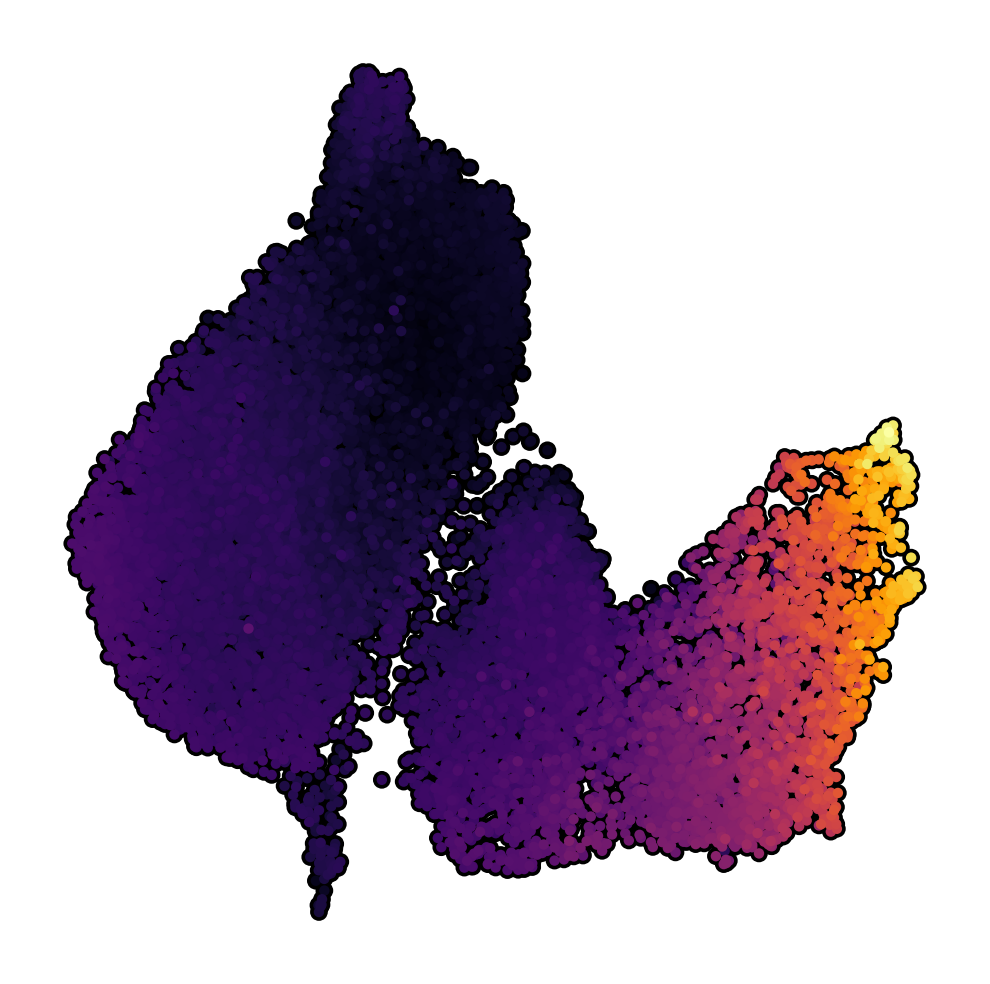

In [16]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color=['G2M_velocity_pseudotime'],
    size=25,
    cmap='inferno',
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    title="",
    frameon=False,
    colorbar_loc=None,
    wspace=0.5,
)

In [17]:
adata

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_pseudotime', 'G1_velocity_pseudotime', 'G2M_velocity_pseudotime', 'mean_velocity_pseudotime'
    var: 'gene_id', 'gene_ty

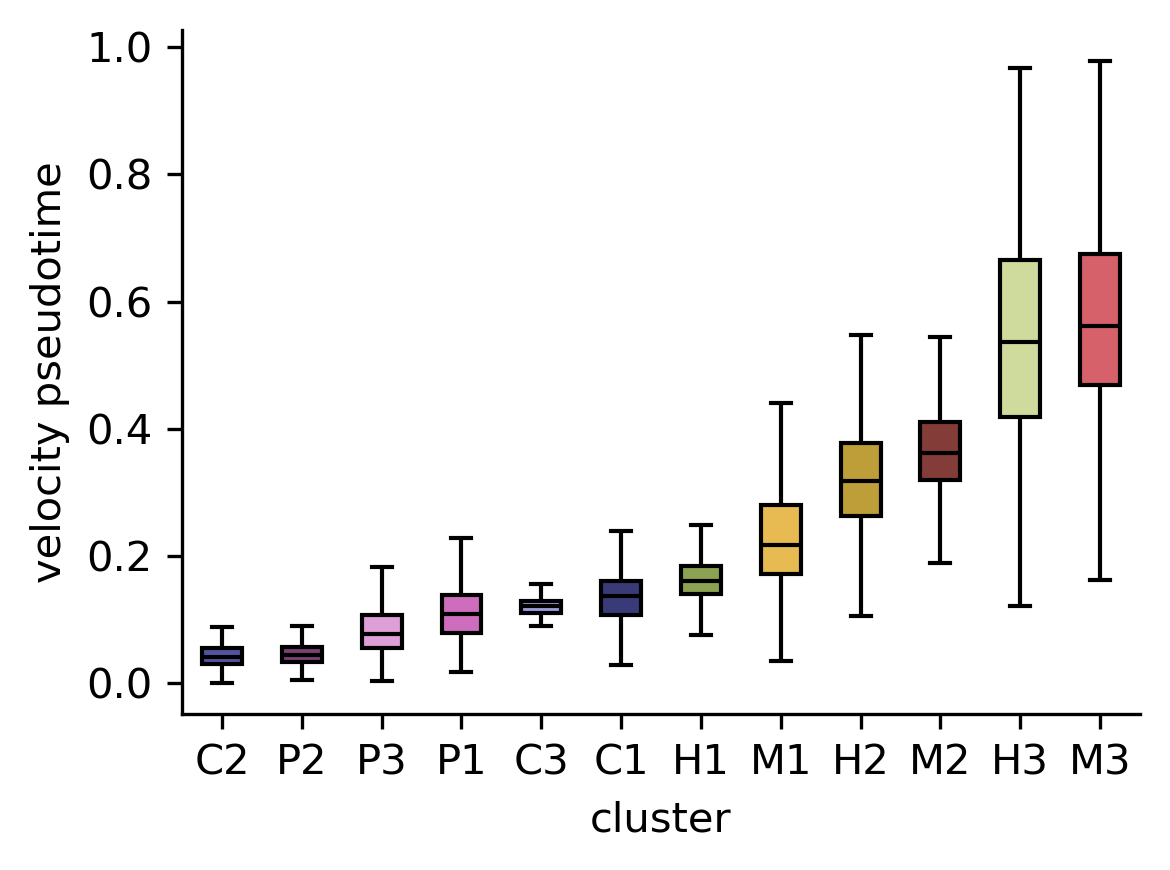

In [26]:
df = pd.DataFrame({
        'pseudotime' : adata.obs['G2M_velocity_pseudotime'].values,
        'cell_id': adata.obs_names,
        'cluster' : adata.obs['leiden_split'].values,
    })

df = df.sort_values(by='pseudotime', ascending=True)
palette = adata.uns['leiden_split_colors']

# take mean to get cluster order
sort_vals = (
    df.groupby('cluster')['pseudotime']
    .median()
    .reset_index()
)

sort_vals = sort_vals.sort_values(by='pseudotime') # smallest first
cluster_order = sort_vals['cluster'].unique()

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 3

sns.boxplot(
    data=df,
    x='cluster',
    y='pseudotime',
    hue='cluster',
    order=cluster_order,
    width=0.5,
    linecolor='k',
    showfliers=False,
    palette=palette,
    saturation=1,
)

plt.ylabel("velocity pseudotime")
plt.xlabel("cluster")

sns.despine()
plt.tight_layout()
plt.show()

# GEX

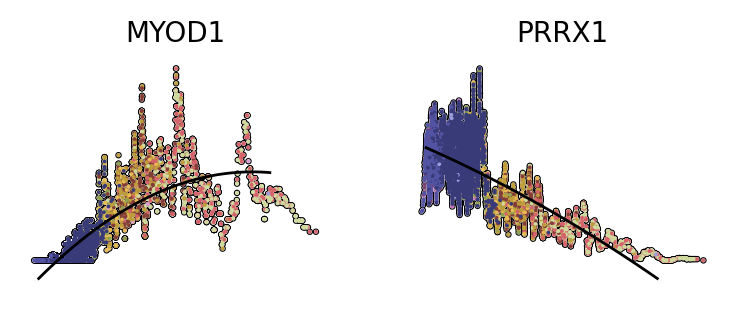

In [33]:
var_names = [
    'MYOD1', 'PRRX1',
]

var_names = [g for g in var_names if g in adata.var_names]

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 2.25, 1.5

scv.pl.scatter(
    adata, 
    x='G2M_velocity_pseudotime', 
    y=var_names, 
    add_polyfit=True,
    ncols=4,
    normalize_data=True,
    add_outline=True,
    frameon=False,
    n_convolve=50,
    smooth=True,
    color='leiden_split',
    wspace=0.25,
    hspace=0.5,
    layer='unspliced',
)

# Correlations

In [36]:
fit_thresh = 0.3
velo_thresh = 0.1

mask = (
    (adata.var['velocity_genes']) &
    (adata.var['fit_r2'] > fit_thresh) &
    (adata.var['velocity_r2'] > velo_thresh)
)

layer = 'log_norm'

pt = adata.obs['G2M_velocity_pseudotime']
X = adata[:, mask].layers[layer].toarray()

cors = np.array([
    spearmanr(X[:, i], pt)[0]
    for i in range(X.shape[1])
])

gene_names = adata.var_names[mask]
cors = pd.Series(cors, index=gene_names)
print(len(cors))

top_pos = cors.sort_values(ascending=False).head(20).index
top_neg = cors.sort_values().head(20).index

selected_genes = list(top_pos) + list(top_neg)

143


Using layer=log_norm...


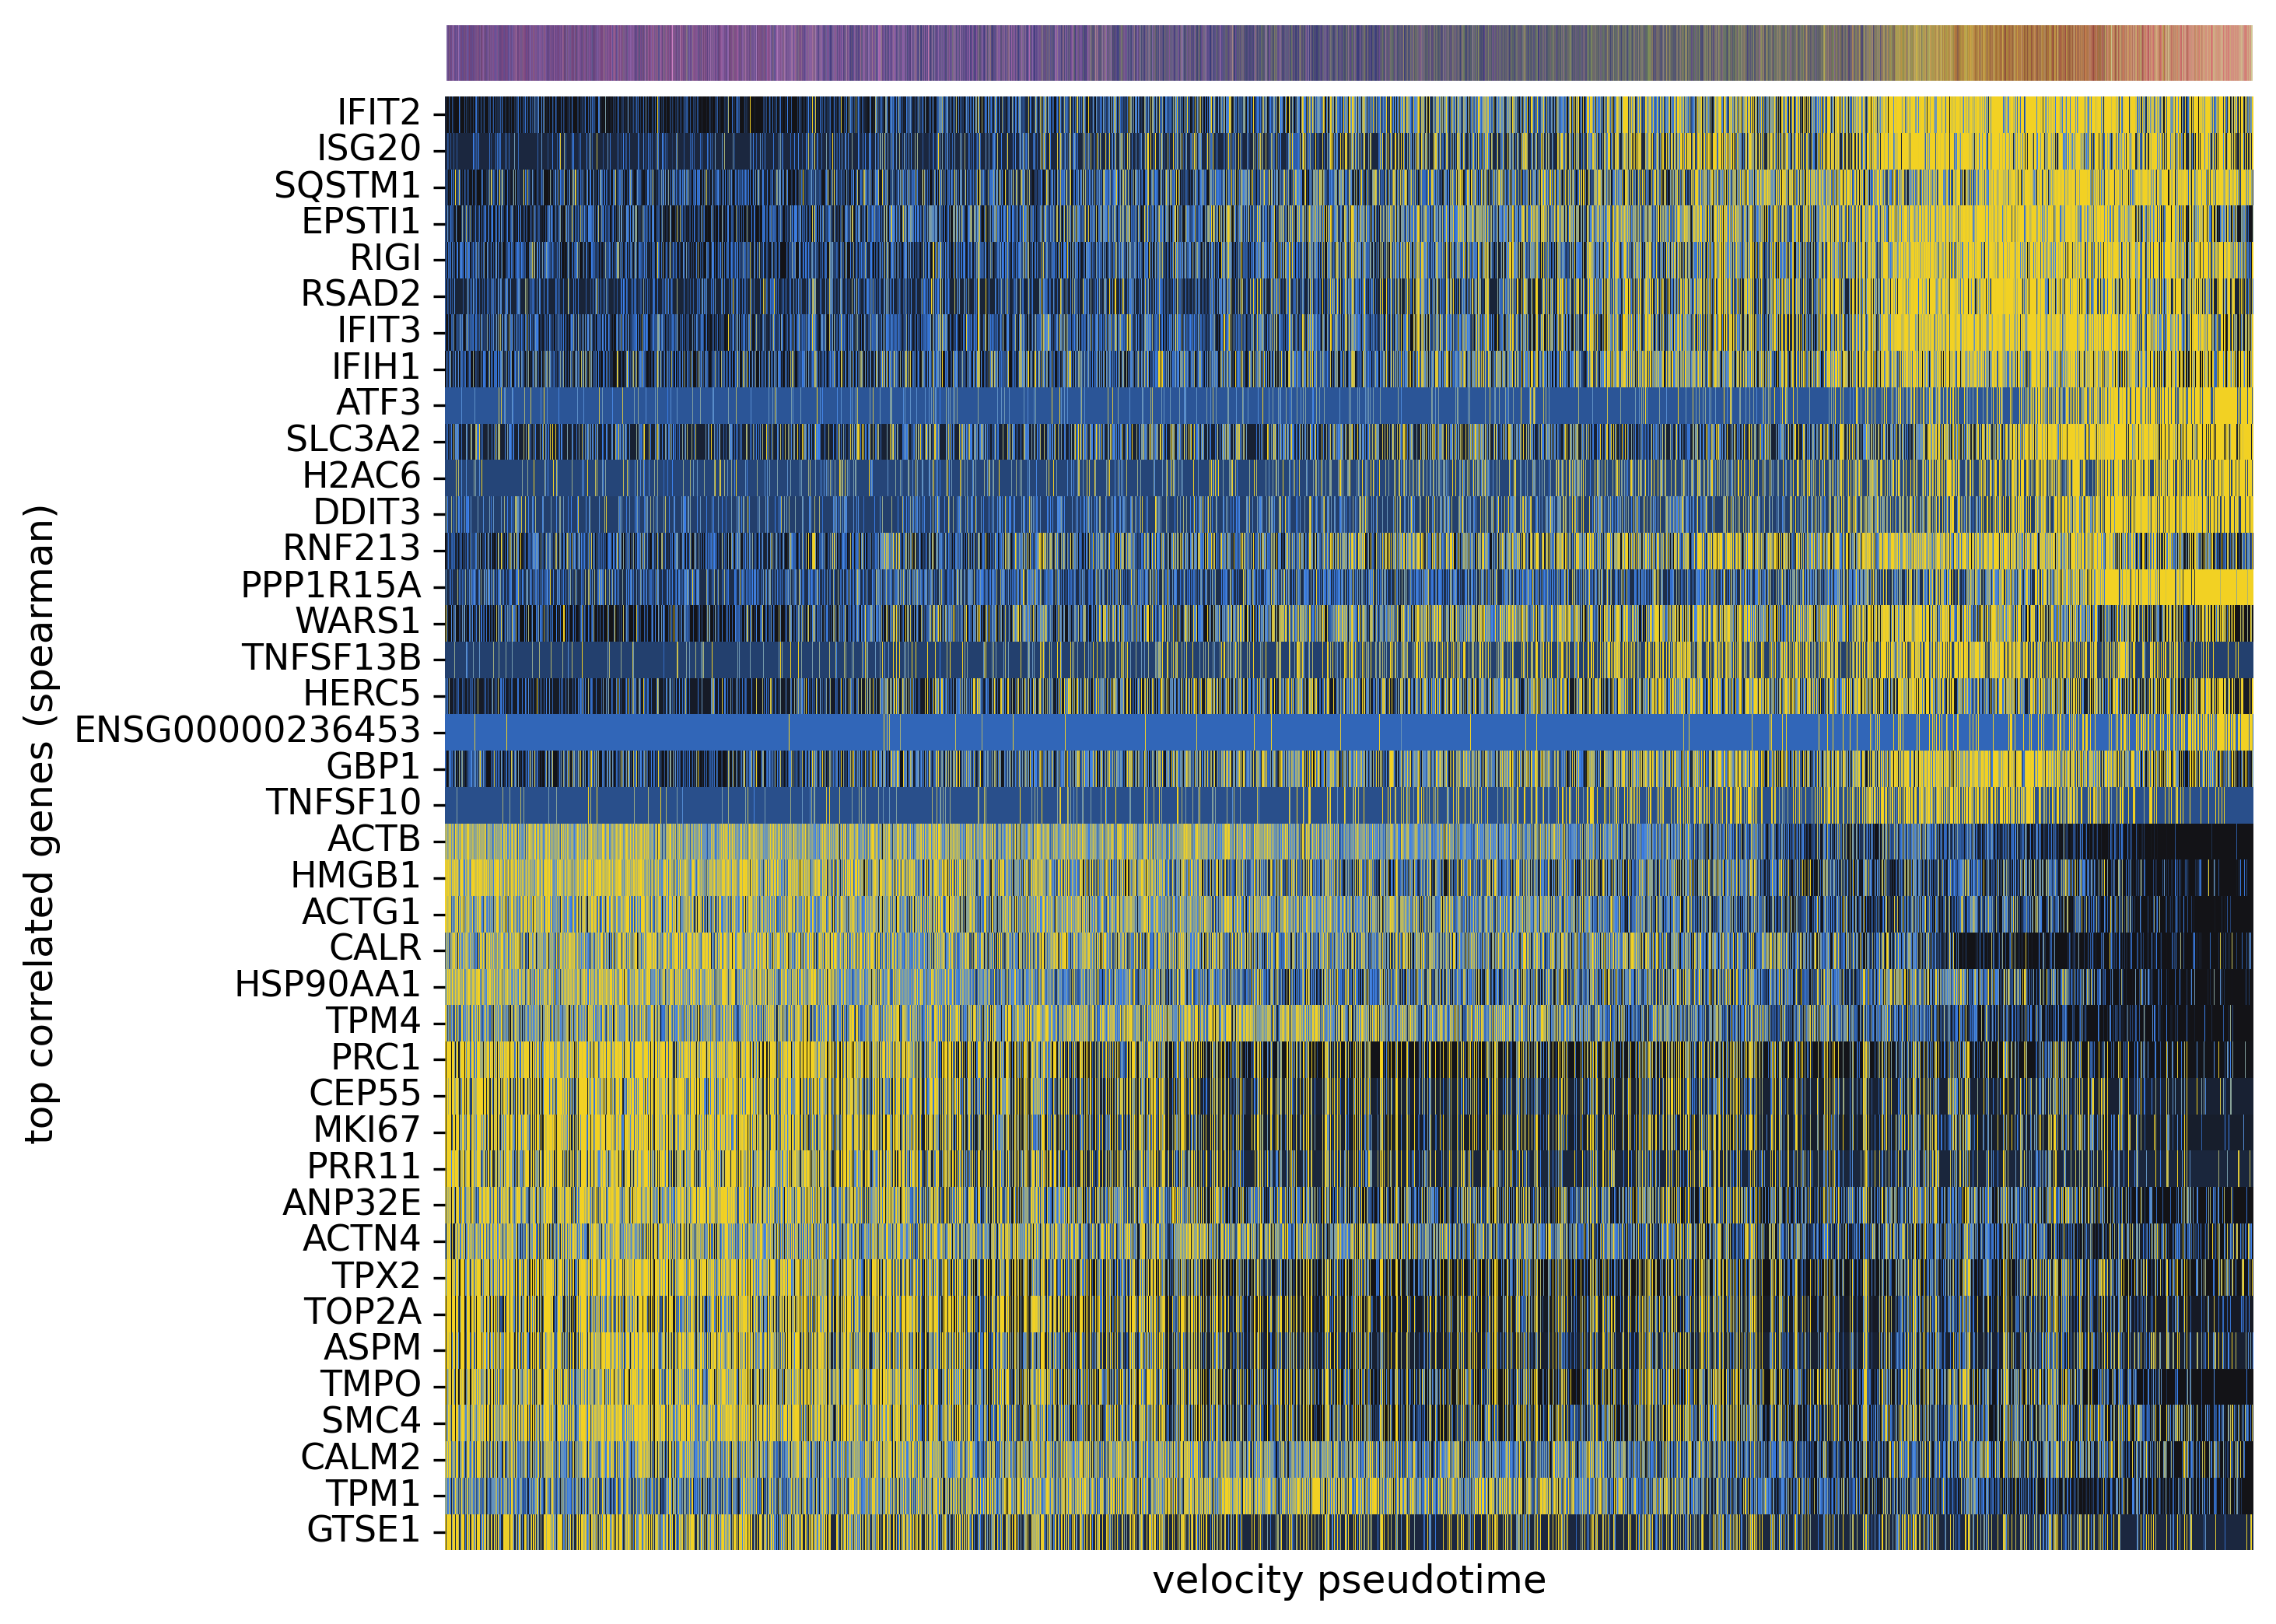

In [37]:
from matplotlib import gridspec
from matplotlib.colors import to_rgba
from matplotlib.colors import LinearSegmentedColormap

low = '#131317' # dark
mid = '#3B80EB' # blue
high = '#F2D123' # yellow

custom_cmap = LinearSegmentedColormap.from_list(
    "custom_cmap",
    [(0.0, low), (0.15, low), (0.5, mid), (0.85, high), (1.0, high)]
)

cell_order = adata.obs.sort_values("G2M_velocity_pseudotime").index
n_cells = len(cell_order)

print(f"Using layer={layer}...")
adata.X = adata.layers[layer].copy()

expr = adata[cell_order, selected_genes].X
if not isinstance(expr, np.ndarray):
    expr = expr.toarray()

# z-score expression
expr_z = zscore(expr, axis=0)

# get bar for cluster order
clusters = adata.obs.loc[cell_order, 'leiden_split']

# mapping: category → color
cluster_colors = dict(zip(
    adata.obs['leiden_split'].cat.categories,
    adata.uns['leiden_split_colors']
))

# convert cluster labels to colors for each cell in order
col_colors = clusters.map(cluster_colors).to_numpy()
rgba_colors = np.array([to_rgba(c) for c in col_colors])


fig = plt.figure(figsize=(10, 8.5), dpi=300)

gs = gridspec.GridSpec(
    2, 1, 
    height_ratios=[0.4, 10],   # small top bar, big heatmap
    hspace=0.02                 # small spacing
)

# --- Top colorbar axis (tiny horizontal strip) ---
ax_color = fig.add_subplot(gs[0])

ax_color.imshow(rgba_colors[np.newaxis, :, :], aspect='auto')
ax_color.set_xlim(0, n_cells)
ax_color.set_xticks([])
ax_color.set_yticks([])
for spine in ax_color.spines.values():
    spine.set_edgecolor('white')

ax_heat = fig.add_subplot(gs[1])

sns.heatmap(
    expr_z.T,
    cmap=custom_cmap,
    xticklabels=False,
    yticklabels=selected_genes,
    vmin=-1.5,
    vmax=1.5,
    cbar=False,
    ax=ax_heat,
)
ax_heat.set_yticklabels(ax_heat.get_yticklabels(), fontsize=11)
ax_heat.set_xlabel("velocity pseudotime", fontsize=12)
ax_heat.set_ylabel("top correlated genes (spearman)", fontsize=12)

plt.tight_layout()
plt.show()

In [38]:
scv.tl.rank_velocity_genes(adata, groupby='leiden_split', min_corr=.3)

df = pd.DataFrame(adata.uns['rank_velocity_genes']['names'])
print(df.head(25).to_string())

ranking velocity genes
    finished (0:02:13) --> added 
    'rank_velocity_genes', sorted scores by group ids (adata.uns) 
    'spearmans_score', spearmans correlation scores (adata.var)
          C1        C2        C3      H1               H3        H2       M1        M2               M3        P2        P1        P3
0      PA2G4     SLFN5      SGO2    HAS2              MX1     WARS1   KIF20B     WARS1              MX1     SLFN5     AURKA     SLFN5
1     CCDC80       LUM       IL6  NUSAP1         HSP90AA1       PTN     NAV3       PTN            WARS1    RNF213     CDCA2    RNF213
2      HLA-B    EPSTI1     GTSE1    KNL1            WARS1    SQSTM1   NUSAP1     BRCA2         HSP90AA1      E2F7     MKI67      CTSK
3       MMP2    EFEMP1     H2AC6  KIF20B  ENSG00000236453    ATP2B1     KNL1       MX1  ENSG00000236453    SMURF2     NUPR1    PCDH18
4       TPM2     RSAD2      ACTB   BRCA2           PAPSS2    PAPSS2    IFIT2    ATP2B1           PAPSS2    PCDH18     POSTN     SPDL1
5      P

# Write out

In [40]:
outpath = "/scratch/indikar_root/indikar1/shared_data/HYB/scvelo/scvelo.h5ad"

adata.write(outpath)
adata

AnnData object with n_obs × n_vars = 15950 × 25042
    obs: 'MYOD-fb_counts', 'PRRX1-fb_counts', 'PRRX1_MYOD-fb_counts', 'assigned_condition', 'total_fb_counts', 'condition_counts_rate', 'G1-fb_counts', 'G2M-fb_counts', 'S-fb_counts', 'dataset', 'total_reads', 'total_genes', 'pooled_condition', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'outlier', 'mt_outlier', 'S_score', 'G2M_score', 'phase', 'leiden', 'cluster_str', 'leiden_split', 'velocyto_cell_id', 'cell_id', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'velocity_self_transition', 'velocity_pseudotime', 'G1_velocity_pseudotime', 'G2M_velocity_pseudotime', 'mean_velocity_pseudotime'
    var: 'gene_id', 'gene_ty